### Group 24

Shiref Khaled Elhalawany -  221100944

Ahmed Anis Hassan - 221100101 

Karim Ashraf Elsayed - 221100391

Kareem Shaheen - 221101524

# Section 1: Statistical Analysis

### Dataset Sampling and Preparation

This code imports the required libraries, loads the MovieLens 20M ratings dataset into a Pandas DataFrame, and standardizes the column names. It then randomly samples a subset of items and users while ensuring minimum dataset requirements are met (at least 10,000 users, 500 items, and 100,000 ratings). The code extracts the UserID, ItemID, and Rating columns into lists for downstream recommendation system processing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RANDOM_STATE = 42
TARGET_MIN_USERS = 10000
TARGET_MIN_ITEMS = 500
TARGET_MIN_RATINGS = 100000

tables_path = '../results/tables/'
plots_path = '../results/plots/'
RAW_DATA_PATH = '../data/ml-20m/ml-20m/ratings.csv'
SAMPLED_DATA_PATH = tables_path + 'sampled_scaled_ratings.csv'

if not os.path.exists(tables_path):
    os.makedirs(plots_path)
if not os.path.exists(plots_path):
    os.makedirs(tables_path)

print("Libraries imported. Settings defined.")

Libraries imported. Settings defined.


In [2]:
def load_and_sample_data(raw_path, output_path):

    print(f"Loading raw data from {raw_path}...")
    df_raw = pd.read_csv(raw_path)
    df_raw.columns = ['UserID', 'ItemID', 'Rating', 'Timestamp']
    
    np.random.seed(RANDOM_STATE)
    
    all_items = df_raw['ItemID'].unique()
    sampled_items = np.random.choice(all_items, size=TARGET_MIN_ITEMS, replace=False) if len(all_items) > TARGET_MIN_ITEMS else all_items
    df_items_subset = df_raw[df_raw['ItemID'].isin(sampled_items)]
    
    selected_users = set()
    
    for item in sampled_items:
        users_who_rated = df_items_subset[df_items_subset['ItemID'] == item]['UserID'].unique()
        if len(users_who_rated) > 0:
            selected_users.add(np.random.choice(users_who_rated))
            
    available_users = df_items_subset['UserID'].unique()
    np.random.shuffle(available_users)
    
    current_ratings = df_items_subset[df_items_subset['UserID'].isin(selected_users)].shape[0]
    
    chunk_size = 2000 
    for i in range(0, len(available_users), chunk_size):
        if len(selected_users) >= TARGET_MIN_USERS and current_ratings >= TARGET_MIN_RATINGS:
            break
            
        chunk = available_users[i : i + chunk_size]
        selected_users.update(chunk)
        
        current_ratings = df_items_subset[df_items_subset['UserID'].isin(selected_users)].shape[0]
   
    df_final = df_items_subset[df_items_subset['UserID'].isin(selected_users)].copy()
    
    return df_final

In [3]:
df = load_and_sample_data(RAW_DATA_PATH, SAMPLED_DATA_PATH)

items = df['ItemID'].tolist()
users = df['UserID'].tolist()
ratings = df['Rating'].tolist()

print(f"\nFinal Dataset Stats:")
print(f"Users: {df['UserID'].nunique()}")
print(f"Items: {df['ItemID'].nunique()}")
print(f"Ratings: {df.shape[0]}")

Loading raw data from ../data/ml-20m/ml-20m/ratings.csv...

Final Dataset Stats:
Users: 28301
Items: 500
Ratings: 105393


### Rating Scale Preprocessing

This code extracts the UserID, ItemID, and Rating columns from the dataset and preprocesses the ratings to ensure they fall within a 1–5 scale. It first identifies and prints the minimum and maximum rating values before adjustment. Each rating is then rounded to the nearest integer and clipped to stay within the valid range of 1 to 5. After preprocessing, the code verifies the new rating range, updates the DataFrame with the scaled values, and saves the cleaned dataset to a CSV file for downstream recommendation system tasks.

In [4]:
ratings = df['Rating'].tolist()
user_ids = df['UserID'].tolist()
movie_ids = df['ItemID'].tolist()

min_rating = None
max_rating = None

for r in ratings:
    if min_rating is None or r < min_rating:
        min_rating = r
    if max_rating is None or r > max_rating:
        max_rating = r

print("\n[Step 2] BEFORE adjustment:")
print("Minimum rating in dataset:", min_rating)
print("Maximum  rating in dataset:", max_rating)

adjusted_ratings = []

for r in ratings:
    new_r = int(r + 0.5)  
    if new_r < 1:
        new_r = 1
    if new_r > 5:
        new_r = 5
    adjusted_ratings.append(float(new_r))

ratings = adjusted_ratings 

min_rating = None
max_rating = None

for r in ratings:
    if min_rating is None or r < min_rating:
        min_rating = r
    if max_rating is None or r > max_rating:
        max_rating = r

print("\n[Step 2] AFTER adjustment:")
print("Minimum rating in dataset:", min_rating)
print("Maximum  rating in dataset:", max_rating)

df['Rating'] = ratings

scaled_df = df.copy()

scaled_ratings_path = SAMPLED_DATA_PATH
scaled_df.to_csv(scaled_ratings_path, index=False)

print("Saved scaled ratings to:", scaled_ratings_path)


[Step 2] BEFORE adjustment:
Minimum rating in dataset: 0.5
Maximum  rating in dataset: 5.0

[Step 2] AFTER adjustment:
Minimum rating in dataset: 1.0
Maximum  rating in dataset: 5.0
Saved scaled ratings to: ../results/tables/sampled_scaled_ratings.csv


### 3.1.1

This code calculates dataset statistics by counting the unique number of users, the unique number of products, and the total number of ratings.


In [5]:
unique_users = set(users)
total_users = len(unique_users)
print(f"Total number of users: {total_users}")

Total number of users: 28301


In [6]:
unique_items = set(items)
total_products = len(unique_items)
print(f"Total number of products: {total_products}")

Total number of products: 500


In [7]:
total_ratings = len(ratings)
print(f"Total number of ratings: {total_ratings}")

Total number of ratings: 105393


### 3.1.2

This part finds the minimum and maximum rating values and prints whether all ratings fall within the 1–5 scale.

In [8]:
min_rating = min(ratings)
max_rating = max(ratings)
if min_rating >= 1 and max_rating <= 5:
    print("All ratings are between 1 and 5.")
else:
    print(f"Ratings are NOT all between 1 and 5. Min: {min_rating}, Max: {max_rating}")

All ratings are between 1 and 5.


### 3.1.3

This section counts how many ratings each user has submitted and stores the results in a dictionary.  

It prints a summary and saves the user–rating counts to a CSV file named:  
`3_1_3_user_counts.csv`

In [9]:
user_counts = {}
for u in users:
    if u in user_counts:
        user_counts[u] += 1
    else:
        user_counts[u] = 1

print(f"Number of ratings per user calculated for {len(user_counts)} users.")

print(f"Example user count: {list(user_counts.items())[0]}")

pd.DataFrame(user_counts.items(), columns=['User', 'Count']).to_csv(tables_path + '3_1_3_user_counts.csv', index=False)

Number of ratings per user calculated for 28301 users.
Example user count: (1, 1)


### 3.1.4

This part counts how many ratings each item has received and stores the results in a dictionary.  

It prints a summary and saves the item–rating counts to a CSV file named:  
`3_1_4_item_counts.csv`

In [10]:
item_counts = {}
for i in items:
    if i in item_counts:
        item_counts[i] += 1
    else:
        item_counts[i] = 1

print(f"Number of ratings per item calculated for {len(item_counts)} items.")

print(f"Example item count: {list(item_counts.items())[0]}")

pd.DataFrame(item_counts.items(), columns=["item", "count"]).to_csv(tables_path + "3_1_4_item_counts.csv", index=False)

Number of ratings per item calculated for 500 items.
Example item count: (3030, 1043)


### 3.1.5

This section sums all ratings for each user, calculates their average rating, and stores the results in a dictionary.  

It prints a sample output and saves the averages to a CSV file named:  
`3_1_5_user_avgs.csv`

In [11]:
user_sums = {}
for u, r in zip(users, ratings):
    if u in user_sums:
        user_sums[u] += r
    else:
        user_sums[u] = r

user_avgs = {}
for u in user_counts:
    user_avgs[u] = round(user_sums[u] / user_counts[u],2)

print("Average ratings per user calculated.")
print(f"Example user avg: {list(user_avgs.items())[0]}")

pd.DataFrame(user_avgs.items(), columns=["user", "avg"]).to_csv(tables_path + "3_1_5_user_avgs.csv", index=False)

Average ratings per user calculated.
Example user avg: (1, 3.0)


### 3.1.6

This part calculates the sum of ratings for each item, then computes the average rating for every item.  

It prints a sample result and exports two CSV files:  
- `3_1_6_item_sums.csv` → total rating per item  
- `3_1_6_item_avgs.csv` → average rating per item

In [12]:
item_sums = {}
for i, r in zip(items, ratings):
    if i in item_sums:
        item_sums[i] += r
    else:
        item_sums[i] = r

item_avgs = {}
for i in item_counts:
    item_avgs[i] = round(item_sums[i] / item_counts[i],2)

print("Average ratings per item calculated.")
print(f"Example item avg: {list(item_avgs.items())[0]}")

pd.DataFrame(list(item_sums.items()), columns=["item", "sum"]).to_csv(tables_path + "3_1_6_item_sums.csv", index=False)
pd.DataFrame(list(item_avgs.items()), columns=["item", "avg"]).to_csv(tables_path + "3_1_6_item_avgs.csv", index=False)

Average ratings per item calculated.
Example item avg: (3030, 4.33)


### 3.1.7

This section sorts items by the number of ratings they received and plots the distribution using a line chart to visualize item popularity.

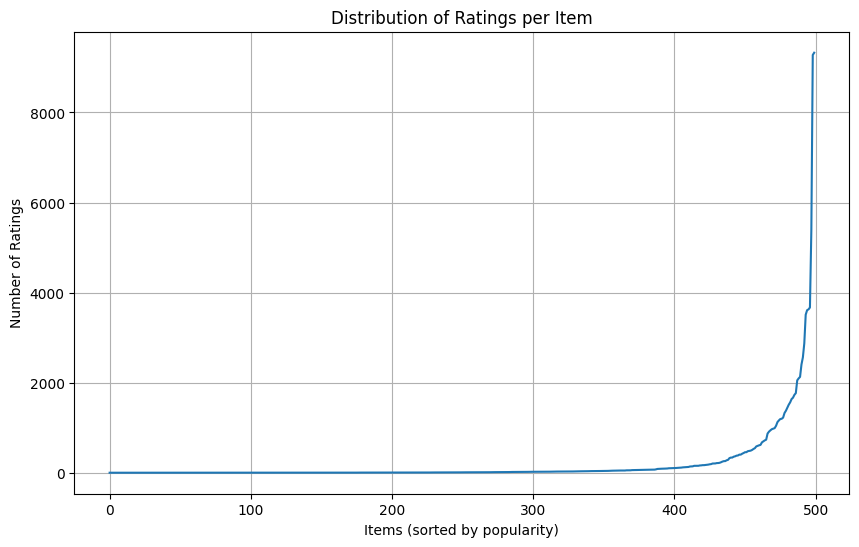

In [13]:
sorted_item_counts = sorted(item_counts.values())

plt.figure(figsize=(10, 6))
plt.plot(sorted_item_counts)
plt.xlabel('Items (sorted by popularity)')
plt.ylabel('Number of Ratings')
plt.title('Distribution of Ratings per Item')
plt.grid(True)
plt.savefig(plots_path + '3_1_7_ratings_distribution.png')
plt.show()

### 3.1.8

This section converts each item's average rating into a percentage of the maximum rating (5.0).  

It then categorizes items into ten predefined groups (G1–G10), based on rating percentage ranges, and prints the number of items in each group along with their corresponding rating ranges.

In [14]:
groups = {
    'G1': [], 'G2': [], 'G3': [], 'G4': [], 'G5': [],
    'G6': [], 'G7': [], 'G8': [], 'G9': [], 'G10': []
}

group_ranges = {
    'G1':  (0, 1),
    'G2':  (1, 5),
    'G3':  (5, 10),
    'G4':  (10, 20),
    'G5':  (20, 30),
    'G6':  (30, 40),
    'G7':  (40, 50),
    'G8':  (50, 60),
    'G9':  (60, 70),
    'G10': (70, 100)
}

for item, avg in item_avgs.items():
    percentage = (avg / 5.0) * 100
    if percentage <= 1:
        groups['G1'].append(item)
    elif percentage <= 5:
        groups['G2'].append(item)
    elif percentage <= 10:
        groups['G3'].append(item)
    elif percentage <= 20:
        groups['G4'].append(item)
    elif percentage <= 30:
        groups['G5'].append(item)
    elif percentage <= 40:
        groups['G6'].append(item)
    elif percentage <= 50:
        groups['G7'].append(item)
    elif percentage <= 60:
        groups['G8'].append(item)
    elif percentage <= 70:
        groups['G9'].append(item)
    else:
        groups['G10'].append(item)


print("Number of products per group (with percentage & rating ranges):")
for g, items_in_g in groups.items():
    low_p, high_p = group_ranges[g]

    low_r = round((low_p / 100) * 5.0, 2)
    high_r = round((high_p / 100) * 5.0, 2)

    print(f"{g}: {len(items_in_g)} items   "
          f"(Range: {low_p}% - {high_p}% | Rating Scale: {low_r} - {high_r})")

Number of products per group (with percentage & rating ranges):
G1: 0 items   (Range: 0% - 1% | Rating Scale: 0.0 - 0.05)
G2: 0 items   (Range: 1% - 5% | Rating Scale: 0.05 - 0.25)
G3: 0 items   (Range: 5% - 10% | Rating Scale: 0.25 - 0.5)
G4: 12 items   (Range: 10% - 20% | Rating Scale: 0.5 - 1.0)
G5: 3 items   (Range: 20% - 30% | Rating Scale: 1.0 - 1.5)
G6: 25 items   (Range: 30% - 40% | Rating Scale: 1.5 - 2.0)
G7: 18 items   (Range: 40% - 50% | Rating Scale: 2.0 - 2.5)
G8: 101 items   (Range: 50% - 60% | Rating Scale: 2.5 - 3.0)
G9: 137 items   (Range: 60% - 70% | Rating Scale: 3.0 - 3.5)
G10: 204 items   (Range: 70% - 100% | Rating Scale: 3.5 - 5.0)


### 3.1.9

This part calculates the total number of ratings within each item group and stores the results in a dictionary.  

It then prints the totals in both unordered and sorted order to show how groups compare in popularity.

In [15]:
group_ratings = {}
for g, items_in_g in groups.items():
    total = 0
    for item in items_in_g:
        total = total + item_counts[item]
    group_ratings[g] = total

print("Total ratings per group (Unordered):")
print(group_ratings)

sorted_group_ratings = dict(sorted(group_ratings.items(), key=lambda item: item[1]))
print("\nTotal ratings per group (Ordered):")
print(sorted_group_ratings)

Total ratings per group (Unordered):
{'G1': 0, 'G2': 0, 'G3': 0, 'G4': 14, 'G5': 9, 'G6': 254, 'G7': 767, 'G8': 18412, 'G9': 32549, 'G10': 53388}

Total ratings per group (Ordered):
{'G1': 0, 'G2': 0, 'G3': 0, 'G5': 9, 'G4': 14, 'G6': 254, 'G7': 767, 'G8': 18412, 'G9': 32549, 'G10': 53388}


### 3.1.10

This section visualizes the total ratings for each item group using bar charts.  

Two plots are displayed side-by-side: one in the original G1–G10 order, and one sorted by total ratings in ascending order.

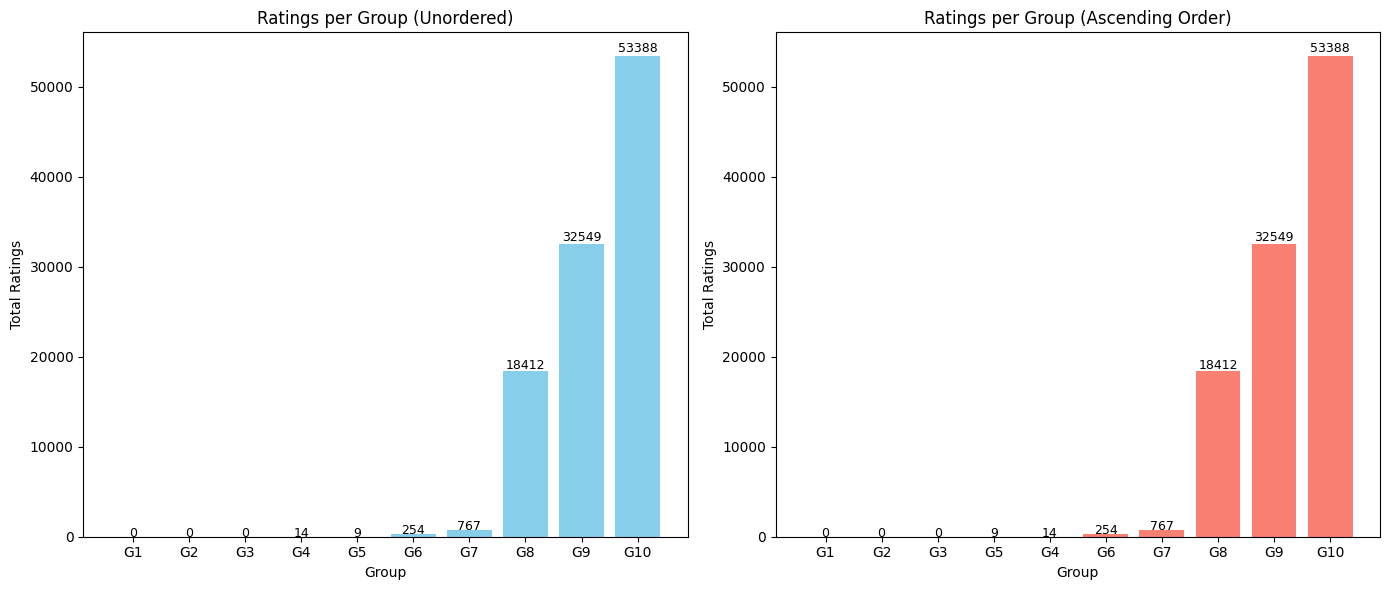

In [16]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(group_ratings.keys(), group_ratings.values(), color='skyblue')

for i, (g, val) in enumerate(group_ratings.items()):
    plt.text(i, val + (val * 0.01), str(val), ha='center', fontsize=9)

plt.title("Ratings per Group (Unordered)")
plt.xlabel("Group")
plt.ylabel("Total Ratings")

plt.subplot(1, 2, 2)
plt.bar(sorted_group_ratings.keys(), sorted_group_ratings.values(), color='salmon')

for i, (g, val) in enumerate(sorted_group_ratings.items()):
    plt.text(i, val + (val * 0.01), str(val), ha='center', fontsize=9)

plt.title("Ratings per Group (Ascending Order)")
plt.xlabel("Group")
plt.ylabel("Total Ratings")

plt.tight_layout()
plt.savefig(plots_path + '3_1_10_group_ratings.png')
plt.show()

### 3.1.11

This part selects three target users based on how many products they rated as a percentage of the total number of products.  

Each target user falls into a specific percentage range, and the selected users are saved in a CSV file named:  
`3_1_11_selected_users.csv`

In [17]:
target_users = {'U1': None, 'U2': None, 'U3': None}

for user, count in user_counts.items():
    percentage = round((count / total_products) * 100,2)
    
    if target_users['U1'] is None and percentage > 0 and percentage <= 2:
        target_users['U1'] = (user, count, percentage)
    elif target_users['U2'] is None and percentage > 2 and percentage <= 5:
        target_users['U2'] = (user, count, percentage)
    elif target_users['U3'] is None and percentage > 10:
        target_users['U3'] = (user, count, percentage)
        
    if all(target_users.values()):
        break

print("Selected Target Users:")
for label, info in target_users.items():
    if info:
        print(f"{label}: UserID={info[0]}, Ratings={info[1]}, Percentage={info[2]:.4f}%")
    else:
        print(f"{label}: Not found")

selected_users = pd.DataFrame(target_users.values(), columns=['UserID', 'Ratings', 'Percentage'])
selected_users.to_csv(tables_path + '3_1_11_selected_users.csv', index=False)

Selected Target Users:
U1: UserID=1, Ratings=1, Percentage=0.2000%
U2: UserID=134, Ratings=14, Percentage=2.8000%
U3: UserID=903, Ratings=56, Percentage=11.2000%


### 3.1.12

This section identifies two target items by sorting all items first by lowest average rating and then by highest number of ratings.  

The top two items from this sorted list are selected as `I1` and `I2`, and their ItemID, AvgRating, and NumRatings are saved to:  
`3_1_12_selected_items.csv`

In [18]:
sorted_items = sorted(
    item_avgs.keys(),
    key=lambda i: (item_avgs[i], -item_counts[i])
)

i1 = sorted_items[0]
i2 = sorted_items[1]

target_items = {
    'I1': (i1, item_avgs[i1], item_counts[i1]),
    'I2': (i2, item_avgs[i2], item_counts[i2])
}

print("Selected Target Items (Lowest AvgRating + Highest NumRatings):")
for label, (item_id, avg, cnt) in target_items.items():
    print(f"{label}: ItemID={item_id}, AvgRating={avg:.2f}, NumRatings={cnt}")

selected_items = pd.DataFrame([
    {"ItemID": target_items["I1"][0], "AvgRating": target_items["I1"][1], "NumRatings": target_items["I1"][2]},
    {"ItemID": target_items["I2"][0], "AvgRating": target_items["I2"][1], "NumRatings": target_items["I2"][2]},
])
selected_items.to_csv(tables_path + '3_1_12_selected_items.csv', index=False)

Selected Target Items (Lowest AvgRating + Highest NumRatings):
I1: ItemID=99904, AvgRating=1.00, NumRatings=2
I2: ItemID=119705, AvgRating=1.00, NumRatings=2


### 3.1.13

This section builds two lookup maps:  
- `user_items`: items rated by each user  
- `item_users`: users who rated each item  

Using the selected target users, it computes how many items each target user co-rated with every other user, prints the results, and saves them to:  
`3_1_13_co_rating_users.csv`  

Using the selected target items, it computes how many users co-rated each target item with every other item, prints the results, and saves them to:  
`3_1_13_co_rating_items.csv`  

Summary statistics are printed for both target users and target items, including the number of co-raters/co-rated items, maximum common counts, and average common counts.

In [19]:
user_items = {}
for u, i in zip(users, items):
    if u not in user_items:
        user_items[u] = set()
    user_items[u].add(i)

print("User-Items map built.")

co_rating_counts = {}
target_user_ids = []

for label, info in target_users.items():
    if info is not None:
        target_user_ids.append(info[0])


for target_u in target_user_ids:
    target_set = user_items[target_u]
    co_rating_counts[target_u] = {}
    
    for other_u, other_set in user_items.items():
        if other_u == target_u:
            continue
            
        common_count = len(target_set.intersection(other_set))
        if common_count > 0:
            co_rating_counts[target_u][other_u] = common_count

rows = []
print("\nNumber of Co-Rated Items with Each Target User:")
for target_u in co_rating_counts:
    print(f"\nTarget User = {target_u}")
    for other_user, count in co_rating_counts[target_u].items():
        rows.append([target_u, other_user, count])
        print(f"  With {other_user}: {count} common items")


df_coratings = pd.DataFrame(rows, columns=["TargetUser", "OtherUser", "CommonItems"])

df_coratings.to_csv("../results/tables/3_1_13_co_rating_users.csv", index=False)
print("\nCSV saved successfully: co_rating_users.csv")

print("Co-rating analysis complete.")
for target_u in target_user_ids:
    num_coraters = len(co_rating_counts[target_u])
    if num_coraters > 0:
        max_common = max(co_rating_counts[target_u].values())
        avg_common = int(round(sum(co_rating_counts[target_u].values()) / num_coraters))
    else:
        max_common = 0
        avg_common = 0
        
    print(f"Target User {target_u}: Co-rating with {num_coraters} users. Max common items: {max_common}, Avg common items: {avg_common:.2f}")

User-Items map built.

Number of Co-Rated Items with Each Target User:

Target User = 1
  With 77: 1 common items
  With 162: 1 common items
  With 248: 1 common items
  With 359: 1 common items
  With 370: 1 common items
  With 598: 1 common items
  With 710: 1 common items
  With 903: 1 common items
  With 969: 1 common items
  With 982: 1 common items
  With 1140: 1 common items
  With 1159: 1 common items
  With 1358: 1 common items
  With 1446: 1 common items
  With 1746: 1 common items
  With 1813: 1 common items
  With 1839: 1 common items
  With 1927: 1 common items
  With 1972: 1 common items
  With 2024: 1 common items
  With 2047: 1 common items
  With 2107: 1 common items
  With 2177: 1 common items
  With 2378: 1 common items
  With 2514: 1 common items
  With 2601: 1 common items
  With 2626: 1 common items
  With 2702: 1 common items
  With 2718: 1 common items
  With 2751: 1 common items
  With 2762: 1 common items
  With 2907: 1 common items
  With 3108: 1 common items

In [20]:
item_users = {}
for u, i in zip(users, items):
    if i not in item_users:
        item_users[i] = set()
    item_users[i].add(u)
print("Item-Users map built.")

target_item_ids = []
for label, info in target_items.items():
    if info is not None:
        target_item_ids.append(info[0])

co_rated_items = {} 
for target_i in target_item_ids:
    target_set = item_users[target_i]
    co_rated_items[target_i] = {}
    
    for other_i, other_set in item_users.items():
        if other_i == target_i:
            continue
        
        common_count = len(target_set.intersection(other_set))
        
        if common_count > 0:
            co_rated_items[target_i][other_i] = common_count

rows = []
print("\nNumber of Co-Rated Users for Each Target Item:")
for target_i in co_rated_items:
    print(f"\nTarget Item = {target_i}")
    for other_item, count in co_rated_items[target_i].items():
        rows.append([target_i, other_item, count])
        print(f"  With {other_item}: {count} common users")

df_item_coratings = pd.DataFrame(rows, columns=["TargetItem", "OtherItem", "CommonUsers"])
df_item_coratings.to_csv("../results/tables/3_1_13_co_rating_items.csv", index=False)

print("\nCSV saved successfully: co_rating_items.csv")

print("\nItem Co-rating summary:")
for target_i in target_item_ids:
    num_co_items = len(co_rated_items[target_i])
    
    if num_co_items > 0:
        max_common = max(co_rated_items[target_i].values())
        avg_common = int(round(sum(co_rated_items[target_i].values()) / num_co_items))
    else:
        max_common = 0
        avg_common = 0
    
    print(f"Target Item {target_i}:")
    print(f"  Co-rated with {num_co_items} items")
    print(f"  Max common users: {max_common}")
    print(f"  Avg common users: {avg_common:.2f}")

Item-Users map built.

Number of Co-Rated Users for Each Target Item:

Target Item = 99904
  With 788: 1 common users
  With 231: 1 common users
  With 34: 1 common users
  With 8873: 1 common users
  With 8983: 1 common users
  With 32031: 1 common users
  With 70286: 1 common users
  With 93510: 2 common users
  With 3968: 1 common users
  With 5872: 1 common users
  With 1713: 1 common users
  With 80432: 1 common users
  With 96514: 1 common users
  With 100344: 1 common users
  With 104638: 1 common users
  With 59501: 1 common users
  With 92507: 1 common users
  With 111364: 1 common users
  With 114060: 1 common users
  With 26502: 1 common users
  With 110127: 1 common users
  With 3012: 1 common users
  With 62439: 1 common users
  With 36289: 1 common users
  With 126749: 1 common users

Target Item = 119705
  With 32031: 1 common users
  With 70286: 1 common users
  With 3968: 1 common users
  With 59501: 1 common users

CSV saved successfully: co_rating_items.csv

Item Co-

### 3.1.14

This section determines threshold values based on co-rating behavior:

1️. For each target user, it calculates how many users co-rated at least **30% of the items rated by the target user**, storing results in `beta_per_target` and selecting the maximum as **β**.

2️. It also calculates how many users co-rated at least **30% of all items in the dataset** with each target user, storing results in `beta_all_per_target` and selecting the maximum as **β_all**.

Both threshold values and detailed statistics are printed for interpretation.

In [21]:
beta_per_target = {}

print("\nThreshold analysis (30% of items per target user):")

for target_u in target_user_ids:
    num_items_target = len(user_items[target_u])
    
    min_common_items = 0.3 * num_items_target
    
    count_users_meeting_threshold = 0
    for other_u, common_count in co_rating_counts[target_u].items():
        if common_count >= int(round(min_common_items)):
            count_users_meeting_threshold += 1
    
    beta_per_target[target_u] = count_users_meeting_threshold
    
    print(f"Target User {target_u}:")
    print(f"  Items rated by target user       = {num_items_target}")
    print(f"  30% threshold (items)           = {min_common_items}")
    print(f"  Users meeting this threshold    = {count_users_meeting_threshold}")

if beta_per_target:
    beta = max(beta_per_target.values())
else:
    beta = 0

print(f"\nβ (max number of users co-rating ≥30% items with a target user) = {beta}")


Threshold analysis (30% of items per target user):
Target User 1:
  Items rated by target user       = 1
  30% threshold (items)           = 0.3
  Users meeting this threshold    = 1042
Target User 134:
  Items rated by target user       = 14
  30% threshold (items)           = 4.2
  Users meeting this threshold    = 2763
Target User 903:
  Items rated by target user       = 56
  30% threshold (items)           = 16.8
  Users meeting this threshold    = 313

β (max number of users co-rating ≥30% items with a target user) = 2763


In [22]:
beta_all_per_target = {}

print("\nThreshold analysis (30% of ALL items in the dataset):")

min_common_items_all = 0.3 * total_products
print(f"\nTotal products = {total_products}")
print(f"30% of ALL items = {min_common_items_all:.2f}")

for target_u in target_user_ids:
    count_users_meeting_threshold_all = 0
    
    if target_u in co_rating_counts:
        for other_u, common_count in co_rating_counts[target_u].items():
            if common_count >= min_common_items_all:
                count_users_meeting_threshold_all += 1
    
    beta_all_per_target[target_u] = count_users_meeting_threshold_all
    
    print(f"\nTarget User {target_u}:")
    print(f"  Users co-rating ≥ 30% of ALL items = {count_users_meeting_threshold_all}")

if beta_all_per_target:
    beta_all = max(beta_all_per_target.values())
else:
    beta_all = 0

print(f"\nβ_all (max number of users co-rating ≥30% of ALL items with a target user) = {beta_all}")
print("β_all per target user:", beta_all_per_target)


Threshold analysis (30% of ALL items in the dataset):

Total products = 500
30% of ALL items = 150.00

Target User 1:
  Users co-rating ≥ 30% of ALL items = 0

Target User 134:
  Users co-rating ≥ 30% of ALL items = 0

Target User 903:
  Users co-rating ≥ 30% of ALL items = 0

β_all (max number of users co-rating ≥30% of ALL items with a target user) = 0
β_all per target user: {1: 0, 134: 0, 903: 0}


### User Classification

Classifying users based on the percentage of total items they have rated:
- **Cold user**: ≤ 2% ratings
- **Medium user**: 2% < ratings ≤ 5%
- **Rich user**: > 10% ratings


In [23]:
total_products = df['ItemID'].nunique()

user_counts = df.groupby('UserID')['ItemID'].count()
user_percentages = (user_counts / total_products) * 100

def classify_user(percentage):
    if percentage <= 2:
        return 'Cold'
    elif 2 < percentage <= 5:
        return 'Medium'
    elif percentage > 10:
        return 'Rich'
    else:
        return 'Other'

user_classes = user_percentages.map(classify_user)
user_class_df = pd.DataFrame({'UserID': user_counts.index, 'RatingCount': user_counts.values, 'Percentage': user_percentages.values, 'Group': user_classes.values})

user_class_df.to_csv('../results/tables/user_classification.csv', index=False)
print("User classification saved to ../results/tables/user_classification.csv")
print(user_class_df['Group'].value_counts())

User classification saved to ../results/tables/user_classification.csv
Group
Cold      26454
Medium     1549
Other       250
Rich         48
Name: count, dtype: int64


### Item Popularity Classification

This code groups the dataset by ItemID and counts the number of user ratings for each item. It then uses dataset quantiles (33% and 66%) to define thresholds for low, medium, and high popularity. Each item is classified based on its rating count, and the results are stored in a new DataFrame containing the item ID, total number of ratings, and popularity category. Finally, the item popularity classification is saved to a CSV file, and the distribution of items across popularity levels is printed for analysis.

In [24]:
item_counts = df.groupby('ItemID')['UserID'].count()

low_thresh = item_counts.quantile(0.33)
high_thresh = item_counts.quantile(0.66)

def classify_item(count):
    if count <= low_thresh:
        return 'Low Popularity'
    elif count <= high_thresh:
        return 'Medium Popularity'
    else:
        return 'High Popularity'

item_classes = item_counts.map(classify_item)
item_class_df = pd.DataFrame({'ItemID': item_counts.index, 'RatingCount': item_counts.values, 'Popularity': item_classes.values})

item_class_df.to_csv('../results/tables/item_classification.csv', index=False)
print("Item classification saved to ../results/tables/item_classification.csv")
print(item_class_df['Popularity'].value_counts())

Item classification saved to ../results/tables/item_classification.csv
Popularity
Low Popularity       176
High Popularity      170
Medium Popularity    154
Name: count, dtype: int64
